# M2.Ex2: Automobile Fuel Efficiency

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M2/exercises/ex2_multi-reg.ipynb)

In [70]:
import pandas as pd
import sklearn

## Auto MPG Dataset

The Auto MPG Dataset is a classic benchmark for regression analysis in machine learning. It originally appeared in the 1983 American Statistical Association (ASA) Exposition and was later donated to the UCI Machine Learning Repository by Ross Quinlan in 1993.

The data consists of technical specifications for various car models from the late 1970s and early 1980s, primarily used to predict fuel efficiency (MPG).

- Features: `5` numerical, `3` categorical
- Target: `mpg` (miles per gallon)
- Size: `398` samples
- Source: [Auto MPG Dataset](https://archive.ics.uci.edu/dataset/9/auto+mpg)

### Step 1. Load the data

In [71]:
df= pd.read_csv("/home/mona/Downloads/SAD/AAI/content/datasets/auto-mpg.csv")
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


### Step 2.a Assign variables `X` to the features and `y` to the target

In [120]:

X= df[['cylinders','displacement','horsepower','weight','acceleration','model year', 'origin']]
y= df['mpg']

In [135]:
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

### Step 2.b print the type of each

In [122]:
print(X.dtypes ,"\n")
print(y.dtype)

cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model year        int64
origin            int64
dtype: object 

float64


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [123]:
print('Target Type: Numerical (Continuous)')

Target Type: Numerical (Continuous)


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [124]:
print(f"X (Data Matrix) has: {X.shape[0]} samples and {X.shape[1]} features.")
print(f"y (Target) has: {y.shape[0]} samples.")

X (Data Matrix) has: 398 samples and 7 features.
y (Target) has: 398 samples.


### Step 4. Summarize the distribution of the data

- Use `describe()` for numerical features
- Use `describe()` for cateogrical features

In [125]:
X.describe()

,cylinders,displacement,horsepower,weight,acceleration,model year,origin
count,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [126]:
y.describe()

count    398.000000
mean      23.514573
std        7.815984
min        9.000000
25%       17.500000
50%       23.000000
75%       29.000000
max       46.600000
Name: mpg, dtype: float64

### Step 5. Plot each of the features vs the target

Hint use this: `sns.pairplot(adv,x_vars=['TV','Radio','Newspaper'],y_vars='Sales',height=6,aspect=0.7,kind='reg')`

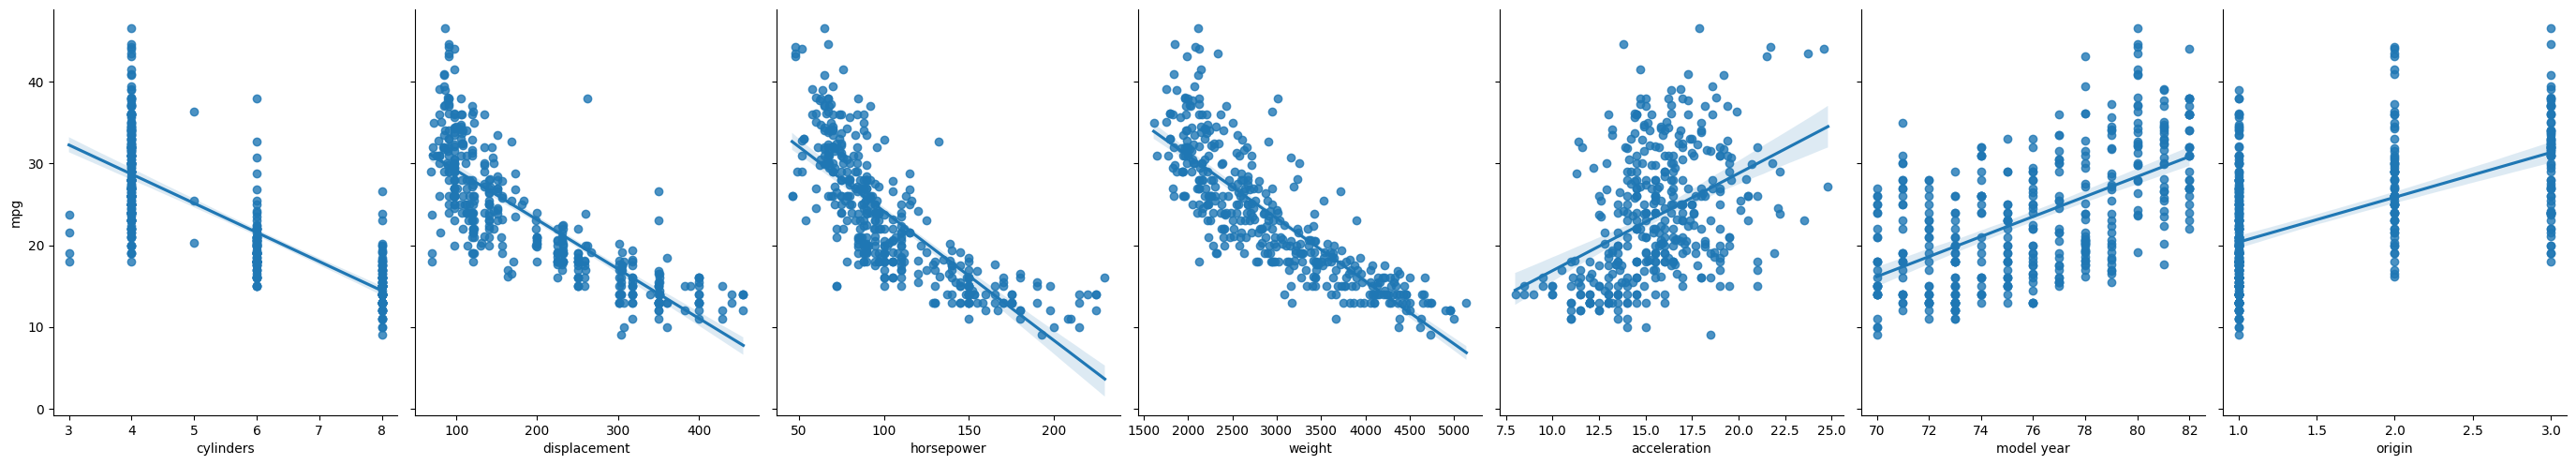

In [127]:
import seaborn as sns
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
sns.pairplot(df, 
             x_vars=['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin'], 
             y_vars='mpg', 
             height=5, 
             aspect=0.8, 
             kind='reg')

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

1. `x=cylinders` and `y=mpg`
2. `x=displacement` and `y=mpg`
3. `x=horsepower` and `y=mpg`
4. `x=weight` and `y=mpg`
5. `x=acceleration` and `y=mpg`

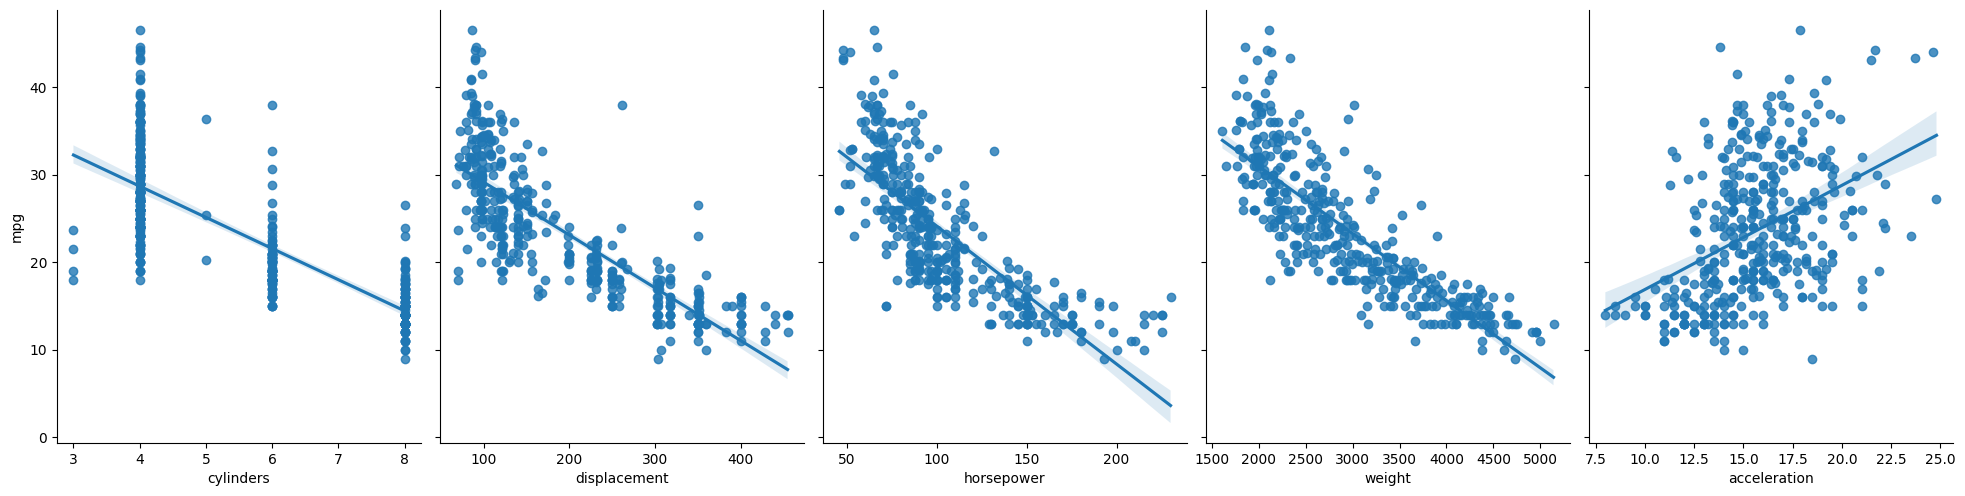

In [128]:

sns.pairplot(df, x_vars=['cylinders', 'displacement', 'horsepower','weight', 'acceleration' ], y_vars='mpg', height=5, aspect=0.8, kind='reg')


### Step 7. Define the pipeline with pre-processing steps

Raw data is rarely ready for use in ML models. We often need steps such as:

- Handling missing values
- Encoding categorical variables
- Scaling numerical variables

Use `ColumnTransformer` to separate the preprocessing steps of the numerical features from the categorical ones.


In [129]:
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

In [130]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression

preprocessor = Pipeline(
    steps= [
        ("imputeer", SimpleImputer(strategy='mean')),
        ("scaler", StandardScaler())

    ]
)
predictor = LinearRegression()



In [131]:

pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", predictor),
    ]
)


### Step 8. Split the dataset into train and test sets

In [132]:

from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Step 9.a Fit the pipeline on the training set

In [133]:
pipe.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('imputeer', ...), ('scaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None


### Step 9.b Identify the learned coefficients (for each feature) and the bias term

In [136]:
model= pipe[-1]
print("Slope (Coefficient):", model.coef_)
print("Bias (Intercept):", model.intercept_)

Slope (Coefficient): [-0.25990572  1.44180107 -0.44238237 -5.68369444  0.20472569  2.86474299
  1.06517559]
Bias (Intercept): 23.60817610062894


### Step 9.c how much `mpg` we gain if we decrease the weight of the automobile by `100kg`?

In [137]:
weight_coef = model.coef_[3]
gain = -100 * weight_coef

print(f"Weight Coefficient: {weight_coef:.4f}")
print(f"If we decrease the weight by 100 units, we gain: {gain:.2f} mpg")

Weight Coefficient: -5.6837
If we decrease the weight by 100 units, we gain: 568.37 mpg


### Step 10. Evaluate the pipeline on the test set

In [138]:
score = pipe.score(X_test, y_test)

In [139]:
print(f"Model Accuracy (R^2 Score): {score:.4f}")

Model Accuracy (R^2 Score): 0.8476
